In [1]:
import os
import sys
import json
from glob import glob
from tqdm import tqdm, trange
import copy

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
sys.path.append('..')

In [3]:
from CRT_utils.CRT.core.dataset import COCODataset, COCODatasetWithID, COCODatasetMixOR, COCODatasetFullMix

In [4]:
with open('../datasets/COCO18_dset_for_CRT_training/val_metadata.json') as file:
    original_test_metadata = json.load(file)

In [5]:
original_test_metadata.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [6]:
image_id_to_image_idx      = {}
annotation_idx_2_image_idx = {}
annotation_id_2_image_idx  = {}
annotation_id_2_area_ratio = {}
area_ratio_ls = []


# _____ PROCESSING IMAGE ID TO IMAGE INDEX _____
for i in trange(len(original_test_metadata['images'])):
    image_metadata = original_test_metadata['images'][i]
    
    image_id = image_metadata['id']
    
    image_id_to_image_idx[image_id] = i
# _____ PROCESSING IMAGE ID TO IMAGE INDEX _____



# _____ PROCESSING ANNOTATION ID AND INDEX TO IMAGE INDEX _____
for i in trange(len(original_test_metadata['annotations'])):
    
    annotation_metadata = original_test_metadata['annotations'][i]
    
    image_id_in_annotation = annotation_metadata['image_id']
    annotation_id          = annotation_metadata['id']
    
    annotation_idx_2_image_idx[i]            = image_id_to_image_idx[image_id_in_annotation]
    annotation_id_2_image_idx[annotation_id] = image_id_to_image_idx[image_id_in_annotation]
# _____ PROCESSING ANNOTATION ID AND INDEX TO IMAGE INDEX _____


# _____ PROCESSING ANNOTATION ID TO AREA RATIO _____
for i in trange(len(original_test_metadata['annotations'])):
    
    annotation_metadata = original_test_metadata['annotations'][i]
    
    annotation_id = annotation_metadata['id']
    
    image_idx_from_annotation = annotation_id_2_image_idx[annotation_id]
    
    image_metadata = original_test_metadata['images'][image_idx_from_annotation]
    
    context_area = image_metadata['width'] * image_metadata['height']
    target_area  = annotation_metadata['bbox'][2] * annotation_metadata['bbox'][3]
    
    area_ratio = target_area / context_area
    
    annotation_id_2_area_ratio[annotation_id] = area_ratio
    
    area_ratio_ls.append(area_ratio)

# _____ PROCESSING ANNOTATION ID TO AREA RATIO _____




100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8879/8879 [00:00<00:00, 2397863.96it/s]


In [7]:
area_ratio_np = np.array(area_ratio_ls)

In [8]:
len(area_ratio_np)

8879

In [9]:
area_ratio_np_mean = area_ratio_np.mean()
area_ratio_np_std  = area_ratio_np.std()

print('Area ratio mean:', area_ratio_np_mean)
print('Area ratio std:', area_ratio_np_std)

Area ratio mean: 0.04801234980454176
Area ratio std: 0.11648967088840129


In [10]:
area_ratio_ls_filtered = [x for x in area_ratio_ls if x > area_ratio_np_mean - 0.233 * area_ratio_np_std]
area_ratio_np_filtered = np.array(area_ratio_ls_filtered)
print('Area ratio filtered mean:', area_ratio_np_filtered.mean())
print('Area ratio filtered std:', area_ratio_np_filtered.std())

Area ratio filtered mean: 0.1271309377434426
Area ratio filtered std: 0.17062111116530043


In [11]:
len(area_ratio_np_filtered)

3106

In [12]:
new_annotation_ls = []

filter_threshold = area_ratio_np_mean - 0.233 * area_ratio_np_std

for i in trange(len(original_test_metadata['annotations'])):
    
    annotation_metadata = original_test_metadata['annotations'][i]
    
    annotation_id = annotation_metadata['id']
    
    if annotation_id_2_area_ratio[annotation_id] > filter_threshold:
        new_annotation_ls.append(annotation_metadata)
        



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8879/8879 [00:00<00:00, 1278536.98it/s]


In [13]:
class_id_2_name = {}

for item_dict in original_test_metadata['categories']:
    class_id_2_name[item_dict['id']] = item_dict['name']

In [14]:
class_count_dict = {} # key -> class name, value -> count

for i in trange(len(new_annotation_ls)):
    annotation_metadata = new_annotation_ls[i]
    
    annotation_metadata_id = annotation_metadata['id']
    
    class_id = annotation_metadata['category_id']
    
    class_name = class_id_2_name[class_id]
    
    if class_name not in class_count_dict:
        class_count_dict[class_name] = 0
    
    class_count_dict[class_name] += 1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3106/3106 [00:00<00:00, 932534.59it/s]


In [15]:
len(class_count_dict)

18

In [16]:
class_count_dict

{'potted plant': 151,
 'tv': 195,
 'bottle': 187,
 'chair': 725,
 'car': 362,
 'clock': 74,
 'cup': 224,
 'fork': 100,
 'knife': 82,
 'bowl': 270,
 'toilet': 156,
 'laptop': 174,
 'mouse': 20,
 'keyboard': 100,
 'microwave': 29,
 'oven': 116,
 'sink': 107,
 'stop sign': 34}

In [17]:
filtered_test_metadata = copy.deepcopy(original_test_metadata)
filtered_test_metadata['annotations'] = new_annotation_ls

In [20]:
with open('../datasets/COCO18_dset_for_CRT_training/filtered_val_metadata.json', 'w') as file:
    json.dump(filtered_test_metadata, file)

In [21]:
dataset = COCODataset(
    '../datasets/COCO18_dset_for_CRT_training/filtered_val_metadata.json', 
    '../datasets/COCO18_dset_for_CRT_training/coco18_for_crt_test', 
    image_size      = (224,224), 
    # _____ ORIGINAL CODE _____
    normalize_means = [0.5, 0.5, 0.5], 
    normalize_stds  = [0.5, 0.5, 0.5],
    # _____ ORIGINAL CODE _____
    
    # _____ MODIFIED VERSION _____
#     normalize_means = [0.5, 0.5, 0.5], 
#     normalize_stds  = [0.5, 5, 0.5]
    # _____ MODIFIED VERSION _____
    
    # _____ ADDED CODE _____
    category_dic_dir = '../datasets/COCO18_dset_for_CRT_training/category_idx_dict.pkl'
    
    # _____ ADDED CODE _____
    
)

reverse_id2id = {value: key for key, value in dataset.id2idx.items()}
id2name = {x['id']: x['name'] for x in dataset.coco_dict['categories']}

-------------------------------
Annotation Counts
-------------------------------
potted plant                151
tv                          195
bottle                      187
chair                       725
car                         362
clock                        74
cup                         224
fork                        100
knife                        82
bowl                        270
toilet                      156
laptop                      174
mouse                        20
keyboard                    100
microwave                    29
oven                        116
sink                        107
stop sign                    34
Total                      3106
-------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tv
target_area/context_area = tensor(0.0794)


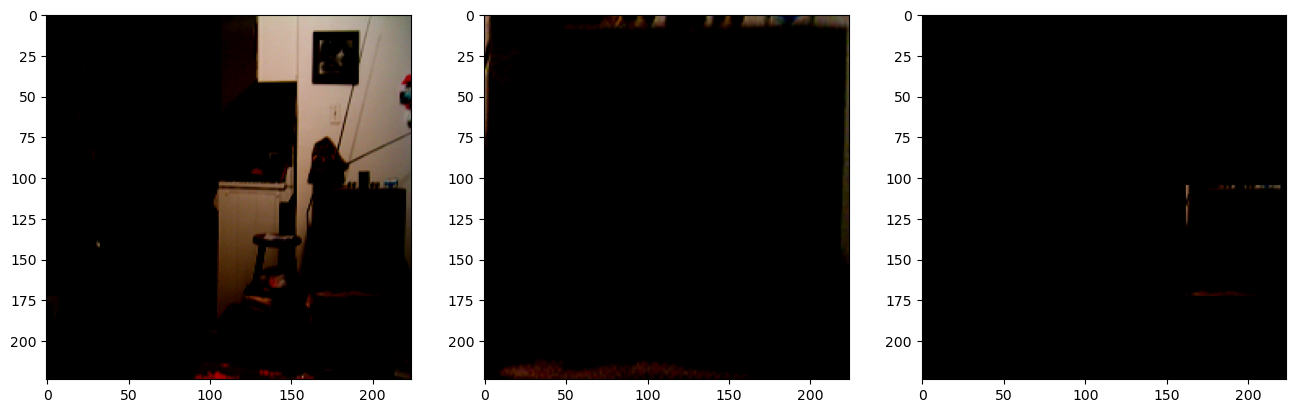

In [42]:
idx = 19

context, target, bbox, category = dataset[idx]

solution = torch.zeros(context.shape[1], context.shape[2])

im_h, im_w = context.shape[1], context.shape[2]
x_min, y_min, w, h = bbox

norm_bbox = int(x_min * im_w), int(y_min * im_h), int(w * im_w), int(h * im_h)

solution[
    norm_bbox[1]:norm_bbox[1]+norm_bbox[3],
    norm_bbox[0]:norm_bbox[0]+norm_bbox[2]
] = 1

fig, ax = plt.subplots(1, 3, figsize=(16, 16))

print(id2name[reverse_id2id[category]])
print('target_area/context_area =', bbox[2]*bbox[3])

ax[0].imshow(context.permute(1,2,0))
ax[1].imshow(target.permute(1,2,0))
ax[2].imshow((context*solution).permute(1,2,0))